In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import os
from skimage.filters import frangi
from skimage.feature import canny
from skimage.transform import probabilistic_hough_line
from skimage.morphology import skeletonize
from skimage.exposure import rescale_intensity
from skimage.filters import threshold_otsu

from scipy.ndimage import convolve
import math
from itertools import combinations

from skimage.measure import shannon_entropy
from skimage.filters.rank import entropy
from skimage.morphology import disk
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
def get_data(type, duplicate=True):
    metadata: dict[str, list[float]] = dict()
    meta_dict: dict[str, dict[str, float]] = dict()

    path = "TRAIN_SET"

    types  = sorted(os.listdir(path))
    print(types)

    def load_real_size(path) -> float:
        with open(path, "r", encoding="latin1", errors="ignore") as f:
            for line in f:
                line = line.strip()

                if line.startswith(r"\Scan Size:"):
                    # example: \Scan Size: 92516.8 nm
                    parts = line.split(":")[1].strip().split()
                    return float(parts[0])  # value in nm

        assert False

    def should_ignore(size):
        return size < 25000

    # loading metadata
    metadata_type = []
    loadpath = path + "/" + type
    meta_dict_type = dict()

    for filename in sorted(os.listdir(loadpath)):
        full_path = os.path.join(loadpath, filename)

        if filename.lower().endswith(".bmp") or  filename.lower().endswith(".bin"):
            continue

        # // check  if there exists a file called filename + "_1.bmp"
        bmp_path = os.path.join(loadpath, filename + "_1.bmp")
        if not os.path.exists(bmp_path):
            print(f"{bmp_path} doesnt exist")
            continue

        size: float = load_real_size(full_path)
        if should_ignore(size):
            print(f"{filename} Ignored! Size {size} too small!")
            continue

        metadata_type.append(size)
        # debug
        meta_dict_type[filename] = size

    meta_dict[type] = meta_dict_type
    metadata[type] = metadata_type;


    print(f"Loaded {len(metadata_type)} images of {type}")

    # loading images and filtering if metadata are available
    images: dict = dict()
    filenames : dict = dict()

    images_type = []
    filenames_type = []
    loadpath = path + "/" + type

    for filename in sorted(os.listdir(loadpath)):
        if filename.lower().endswith(".bmp"):
           # // check  if there exists a file called filename + "_1.bmp"
            meta_path = os.path.join(loadpath, filename.replace("_1.bmp", ""))
            if not os.path.exists(meta_path):
                print(f"{meta_path} doesnt exist!!")
                continue
            if not  filename.replace("_1.bmp", "") in meta_dict[type]:
                print(f"{filename.replace("_1.bmp", "")}  is not existent!!")
                continue

            full_path = os.path.join(loadpath, filename)
            img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                images_type.append(img)
                filenames_type.append(filename)

    print(f"Loaded {len(images_type)} images of {type}")

    # Convert to numpy array (if all same shape)
    images_type = np.array(images_type)
    images[type] = images_type
    filenames[type] = filenames_type


    def crop_image(image_to_crop, top = 10, bottom =  575 - 45, left = 94, right = 704 - 90):
        return image_to_crop[top:bottom, left:right]

    def crop_images(to_crop: list[np.ndarray]):
        cropped = []
        for _img in to_crop:
            cropped.append(crop_image(_img))

        return np.array(cropped, dtype=np.uint8)

    from skimage.morphology import skeletonize
    from skimage.exposure import rescale_intensity
    from skimage.filters import threshold_otsu

    def change_contrast(image, low=10, high=98):
        p_low, p_high = np.percentile(image, (low, high))
        return rescale_intensity(image, in_range=(p_low, p_high))

    def process_skeletons(to_skeletonize):
        processed = []
        skeletons = []
        for img in to_skeletonize:
            img = change_contrast(img)
            th = threshold_otsu(img)
            binary = img > th

            skel = skeletonize(binary)
            skeletons.append(skel)
            processed.append(binary)

        return processed, skeletons

    def normalize(images, metadatas, target=50000.0):
        added_by_cropping = 0

        out = []

        for i in range(len(images)):
            img = images[i]
            area = metadatas[i]

            ratio = target / area  # >1 enlarge, <1 shrink
            h, w = img.shape[:2]

            # # -------------------------
            # # 1. SCALE UP (small images)
            # # -------------------------
            # # 385 is aproximately  50000/92500
            if area < 51000:
                new_w = int(281.0)
                new_h = int(281.0)

                resized = cv2.resize(
                    img,
                    (new_w, new_h),
                    interpolation=cv2.INTER_NEAREST
                )

                out.append(resized)
            # # -------------------------
            # 2. CROP (large images)
            # -------------------------
            else:
                new_w = int(w * ratio)
                new_h = int(h * ratio)
                # center crop
                start_x = (w - new_w) // 2
                start_y = (h - new_h) // 2

                cropped_center = img[
                    start_y:start_y + new_h,
                    start_x:start_x + new_w
                ]
                cropped_tl = img[0:new_h, 0:new_w]
                cropped_tr = img[0:new_h, w-new_w:w]
                cropped_bl = img[h-new_h:h, 0:new_w]
                cropped_br = img[h-new_h:h, w-new_w:w]

                if not duplicate:
                    out.append(cropped_center)
                else:
                    out.append(cropped_tl)
                    out.append(cropped_tr)
                    out.append(cropped_bl)
                    out.append(cropped_br)
                    added_by_cropping += 3

        print(f"Pocet pridaných navyše obrázkov stvtenim {int(added_by_cropping)}")
        return np.array(out)

    normalized: dict[str, list] = dict()

    cropped = crop_images(images[type])

    normalized[type] = normalize(cropped, metadata[type])

    raw_images = normalized[type]

    processed, skeletons = process_skeletons(raw_images)

    return raw_images, processed, skeletons


In [3]:
def box_counting_fractal_dimension(image_array):
    """
    Calculates the fractal dimension of a 2D image using the box-counting method.
    
    Parameters:
    - image_array: 2D NumPy array (can be binary or grayscale, will be binarized > 0)
    
    Returns:
    - fd: The fractal dimension (float), typically between 1.0 and 2.0.
    """
    # 1. Ensure the image is strictly binary (background=0, crystal=1)
    Z = (image_array > 0)
    
    # Extract the Y, X coordinates of all crystal pixels
    pixels = np.argwhere(Z)
    if len(pixels) == 0:
        return 0.0 # Return 0 if the image is completely empty
        
    Ly, Lx = Z.shape
    
    # 2. Define the varying box sizes
    # We create a logarithmic scale of box sizes from 1 pixel up to 1/5th of the image size
    max_box_size = min(Lx, Ly) // 5
    # Generate logarithmically spaced sizes and ensure they are unique integers
    sizes = np.logspace(0.1, np.log10(max_box_size), num=20, base=10)
    sizes = np.unique(np.floor(sizes)).astype(int)
    
    counts = []
    
    # 3. Count the boxes for each grid size
    for size in sizes:
        # Determine the number of boxes in X and Y directions
        Nx = int(np.ceil(Lx / size))
        Ny = int(np.ceil(Ly / size))
        
        # Create the grid boundaries (bins)
        xbins = np.arange(0, Nx * size + 1, size)
        ybins = np.arange(0, Ny * size + 1, size)
        
        # Drop the pixels into the grid using a 2D histogram
        H, _, _ = np.histogram2d(pixels[:, 0], pixels[:, 1], bins=(ybins, xbins))
        
        # Count how many boxes contain at least 1 pixel (H > 0)
        counts.append(np.sum(H > 0))
        
    # 4. Calculate the slope of the line of best fit (Fractal Dimension)
    # x-axis: log(1 / box_size)
    # y-axis: log(number of filled boxes)
    x_vals = np.log(1.0 / sizes)
    y_vals = np.log(counts)
    
    # np.polyfit returns [slope, intercept]
    coeffs = np.polyfit(x_vals, y_vals, 1)
    fractal_dimension = coeffs[0]
    
    return fractal_dimension

def calculate_skeleton_entropies(skeleton_array):
    """
    Calculates both Global and Local entropy for a binary skeleton image.
    """
    # 1. Global Binary Entropy (Effectively measures Skeleton Density)
    global_ent = shannon_entropy(skeleton_array)
    
    # 2. Local Spatial Entropy (Measures structural chaos)
    # Convert skeleton to an 8-bit integer array as required by skimage rank filters
    skel_8bit = (skeleton_array > 0).astype(np.uint8) * 255
    
    # Define the neighborhood size (a circle with a radius of 10 pixels)
    neighborhood = disk(10)
    
    # Calculate entropy for every local neighborhood
    # Catching warnings here because pure black regions might throw a low-contrast warning
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        local_ent_map = entropy(skel_8bit, neighborhood)
    
    # The final feature is the average chaos across the entire image
    mean_local_ent = np.mean(local_ent_map)
    
    return global_ent, mean_local_ent

def fft_metric(cropped_image):
    line_thickness=20
    
    f_transform = np.fft.fft2(cropped_image)
    f_transform_shifted = np.fft.fftshift(f_transform)
    log_magnitude = np.log(np.abs(f_transform_shifted) + 1e-8)

    height, width = cropped_image.shape
    cy, cx = height // 2, width // 2
    mask_radius=100
    percentile=70

    y, x = np.ogrid[-cy:height-cy, -cx:width-cx]
    distance_from_center = np.sqrt(x**2 + y**2)
    min_val = np.min(log_magnitude)
    log_magnitude[distance_from_center <= mask_radius] = min_val

    threshold_value = np.percentile(log_magnitude, percentile)
    binary_fft = (log_magnitude >= threshold_value).astype(int)

    cross_mask = np.zeros_like(binary_fft)
    cross_mask[cy - line_thickness : cy + line_thickness + 1, :] = 1
    cross_mask[:, cx - line_thickness : cx + line_thickness + 1] = 1

    pixels_in_cross = np.sum(binary_fft * cross_mask)
    total_white_pixels = np.sum(binary_fft)

    return pixels_in_cross / (total_white_pixels + 1e-10)


In [4]:
def build_feature_dataframe(cropped_list, bin_list, skel_list, labels):
    data_list = []
    
    # Iterate through all images in your dataset
    for i in range(len(cropped_list)):
        # 1. Extract images from your arrays
        img_crop = cropped_list[i]
        img_bin  = bin_list[i]
        img_skel = skel_list[i]
        label = labels[i]
        
        # 2. Run your previously defined functions
        # FFT Metric (Cropped)
        fft_val = fft_metric(img_crop) # Assuming this returns a single scalar
        
        # Fractal Dimensions
        fd_bin = box_counting_fractal_dimension(img_bin)
        fd_skel = box_counting_fractal_dimension(img_skel)
        
        # Entropies (These return Global and Local)
        glob_ent_bin, loc_ent_bin = calculate_skeleton_entropies(img_bin)
        glob_ent_skel, loc_ent_skel = calculate_skeleton_entropies(img_skel)
        
        # 3. Create a dictionary for this image's features
        features = {
            'fft_score': fft_val,
            'fd_bin': fd_bin,
            'fd_skel': fd_skel,
            'entropy_glob_bin': glob_ent_bin,
            'entropy_loc_bin': loc_ent_bin,
            'entropy_glob_skel': glob_ent_skel,
            'entropy_loc_skel': loc_ent_skel,
            
            # --- Label Columns ---
            'healthy':  1 if label == 'healthy' else 0,
            'diabetes': 1 if label == 'diabetes' else 0,
            'sklerosis': 1 if label == 'sklerosis' else 0,
            'dry_eye':  1 if label == 'dry_eye' else 0,
            'glaucoma': 1 if label == 'glaucoma' else 0,
            
            # --- Binary Classification Label ---
            'unhealthy': 0 if label == 'healthy' else 1
        }
        
        data_list.append(features)
    
    # 4. Convert list of dictionaries to DataFrame
    df = pd.DataFrame(data_list)
    return df

In [5]:
cropped_healthy, binarization_healthy, skeletons_healthy = get_data("ZdraviLudia")
cropped_diabetes, binarization_diabetes, skeletons_diabetes = get_data("Diabetes")
cropped_Sklerosis, binarization_Sklerosis, skeletons_Sklerosis = get_data("SklerozaMultiplex")
cropped_glaucoma, binarization_glaucoma, skeletons_glaucoma = get_data("PGOV_Glaukom")
cropped_dry_eye, binarization_dry_eye, skeletons_dry_eye = get_data("SucheOko")


['Diabetes', 'PGOV_Glaukom', 'SklerozaMultiplex', 'SucheOko', 'ZdraviLudia']
TRAIN_SET/ZdraviLudia\Thumbs.db_1.bmp doesnt exist
Loaded 70 images of ZdraviLudia
Loaded 70 images of ZdraviLudia
Pocet pridaných navyše obrázkov stvtenim 177
['Diabetes', 'PGOV_Glaukom', 'SklerozaMultiplex', 'SucheOko', 'ZdraviLudia']
Loaded 26 images of Diabetes
37_DM_.bmp  is not existent!!
Loaded 26 images of Diabetes
Pocet pridaných navyše obrázkov stvtenim 69
['Diabetes', 'PGOV_Glaukom', 'SklerozaMultiplex', 'SucheOko', 'ZdraviLudia']
1-SM-LM-18.027 Ignored! Size 20000.0 too small!
1-SM-LM-18.029 Ignored! Size 20000.0 too small!
1-SM-LM-18.030 Ignored! Size 10000.0 too small!
1-SM-PM-18.003 Ignored! Size 20000.0 too small!
1-SM-PM-18.007 Ignored! Size 20000.0 too small!
19_PM_SM.001 Ignored! Size 20000.0 too small!
19_PM_SM.066 Ignored! Size 10000.0 too small!
19_PM_SM.072 Ignored! Size 20000.0 too small!
20_LM_SM-SS.004 Ignored! Size 10000.0 too small!
20_LM_SM-SS.011 Ignored! Size 20000.0 too small!
S

In [6]:
all_cropped = np.concatenate([
    cropped_healthy, cropped_diabetes, cropped_Sklerosis, 
    cropped_glaucoma, cropped_dry_eye
], axis=0)

all_binarized = np.concatenate([
    binarization_healthy, binarization_diabetes, binarization_Sklerosis, 
    binarization_glaucoma, binarization_dry_eye
], axis=0)

all_skeletons = np.concatenate([
    skeletons_healthy, skeletons_diabetes, skeletons_Sklerosis, 
    skeletons_glaucoma, skeletons_dry_eye
], axis=0)

all_labels = (
    ['healthy'] * len(cropped_healthy) +
    ['diabetes'] * len(cropped_diabetes) +
    ['sklerosis'] * len(cropped_Sklerosis) +
    ['glaucoma'] * len(cropped_glaucoma) +
    ['dry_eye'] * len(cropped_dry_eye)
)

In [7]:
df = build_feature_dataframe(all_cropped, all_binarized, all_skeletons, all_labels)

image_indices = np.arange(len(all_labels))
df['array_idx'] = image_indices

In [8]:
feature_cols = [
    'fft_score', 'fd_bin', 'fd_skel', 
    'entropy_glob_bin', 'entropy_loc_bin', 
    'entropy_glob_skel', 'entropy_loc_skel'
]

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['unhealthy'], random_state=42
)

scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [9]:
from torch.utils.data import Dataset
import torch

class TearCrystalDataset(Dataset):
    def __init__(self, dataframe, bin_arr, skel_arr, feature_cols):
        self.df = dataframe.reset_index(drop=True)
        self.bin_arr = bin_arr
        self.skel_arr = skel_arr
        self.feature_cols = feature_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        original_idx = int(row['array_idx'])
        
        img_bin = self.bin_arr[original_idx]
        img_skel = self.skel_arr[original_idx]
        
        image_stack = np.stack([img_bin, img_skel], axis=0).astype(np.float32)
        
        features = torch.tensor(row[self.feature_cols].values.astype(np.float32))
        label = torch.tensor(row['unhealthy'], dtype=torch.float32)
        
        return torch.from_numpy(image_stack), features, label

In [10]:
train_dataset = TearCrystalDataset(train_df, all_binarized, all_skeletons, feature_cols)
test_dataset = TearCrystalDataset(test_df, all_binarized, all_skeletons, feature_cols)

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=16, 
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=16, 
    shuffle=False
)

In [11]:
class TearCrystalNet(nn.Module):
    def __init__(self, num_features):
        super(TearCrystalNet, self).__init__()
        
        # --- BRANCH A: CNN for 520x520 Stacked Images ---
        # Input shape: (Batch, 2, 520, 520)
        self.cnn_branch = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Changed from 4x4 to 2x2. 
            # 281x281 becomes roughly 140x140
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # Changed from 4x4 to 2x2. 
            # 140x140 becomes 70x70
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # Add one more 2x2 pool to gently bring it down to 35x35
            nn.MaxPool2d(2, 2),
            
            # The Magic Funnel: gently squashes 35x35 down to exactly 4x4
            nn.AdaptiveAvgPool2d((4, 4)), 
            nn.Flatten()
            )
        
        # 128 channels * 4 * 4 = 2048
        self.cnn_fc = nn.Linear(2048, 64)
        
        # --- BRANCH B: MLP for Feature Vectors ---
        self.mlp_branch = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        
        # --- FUSION TORSO ---
        self.fusion_layers = nn.Sequential(
            nn.Linear(64 + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.4), # Increased slightly to prevent overfitting on small datasets
            nn.Linear(32, 1) # Raw logits output (No Sigmoid here!)
        )

    def forward(self, img_stack, feature_vector):
        x_img = self.cnn_branch(img_stack)
        x_img = F.relu(self.cnn_fc(x_img))
        
        x_feat = self.mlp_branch(feature_vector)
        
        combined = torch.cat((x_img, x_feat), dim=1)
        output = self.fusion_layers(combined)
        
        return output

In [12]:
import torch.optim as optim

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# 2. Initialize Model, Optimizer, and Loss
# feature_cols has 7 features
model = TearCrystalNet(num_features=7).to(device) 
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Handle Class Imbalance (Weighting the 'Healthy' class higher if it's rare)
# We calculate weight: (Number of Negatives / Number of Positives)
# Assuming Label 1 = Unhealthy, Label 0 = Healthy
num_unhealthy = train_df['unhealthy'].sum()
num_healthy = len(train_df) - num_unhealthy
imbalance_weight = torch.tensor([num_healthy / num_unhealthy], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=imbalance_weight)

# 3. Training Loop Variables
epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, features, labels in train_loader:
        # Move data to GPU/CPU
        images, features, labels = images.to(device), features.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward Pass
        outputs = model(images, features).squeeze() # Squeeze removes extra dimensions
        loss = criterion(outputs, labels)
        
        # Backward Pass & Optimize
        loss.backward()
        optimizer.step()
        
        # Calculate Training Accuracy
        running_loss += loss.item() * images.size(0)
        # Apply Sigmoid here just for calculating accuracy predictions
        predictions = torch.round(torch.sigmoid(outputs))
        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    
    # ==========================================
    # VALIDATION PHASE
    # ==========================================
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad(): # Don't calculate gradients to save memory/speed
        for images, features, labels in test_loader: # Assuming you made a test_loader!
            images, features, labels = images.to(device), features.to(device), labels.to(device)
            
            outputs = model(images, features).squeeze()
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            predictions = torch.round(torch.sigmoid(outputs))
            correct_val += (predictions == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val

    scheduler.step(epoch_val_loss)
    
    # Save metrics for plotting later
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    # Print progress
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")

Training on: cpu
Epoch [1/10] | Train Loss: 0.3251, Acc: 0.7147 | Val Loss: 0.2912, Acc: 0.6341
Epoch [2/10] | Train Loss: 0.2741, Acc: 0.7807 | Val Loss: 0.2195, Acc: 0.8841
Epoch [3/10] | Train Loss: 0.2431, Acc: 0.8252 | Val Loss: 0.1979, Acc: 0.8659
Epoch [4/10] | Train Loss: 0.2542, Acc: 0.8083 | Val Loss: 0.2128, Acc: 0.8049
Epoch [5/10] | Train Loss: 0.2446, Acc: 0.8037 | Val Loss: 0.2026, Acc: 0.8659
Epoch [6/10] | Train Loss: 0.2552, Acc: 0.7899 | Val Loss: 0.2066, Acc: 0.7927
Epoch [7/10] | Train Loss: 0.2345, Acc: 0.8144 | Val Loss: 0.1920, Acc: 0.8659
Epoch [8/10] | Train Loss: 0.2164, Acc: 0.8282 | Val Loss: 0.1926, Acc: 0.8659
Epoch [9/10] | Train Loss: 0.2256, Acc: 0.8267 | Val Loss: 0.1920, Acc: 0.8659
Epoch [10/10] | Train Loss: 0.2043, Acc: 0.8482 | Val Loss: 0.2382, Acc: 0.8598


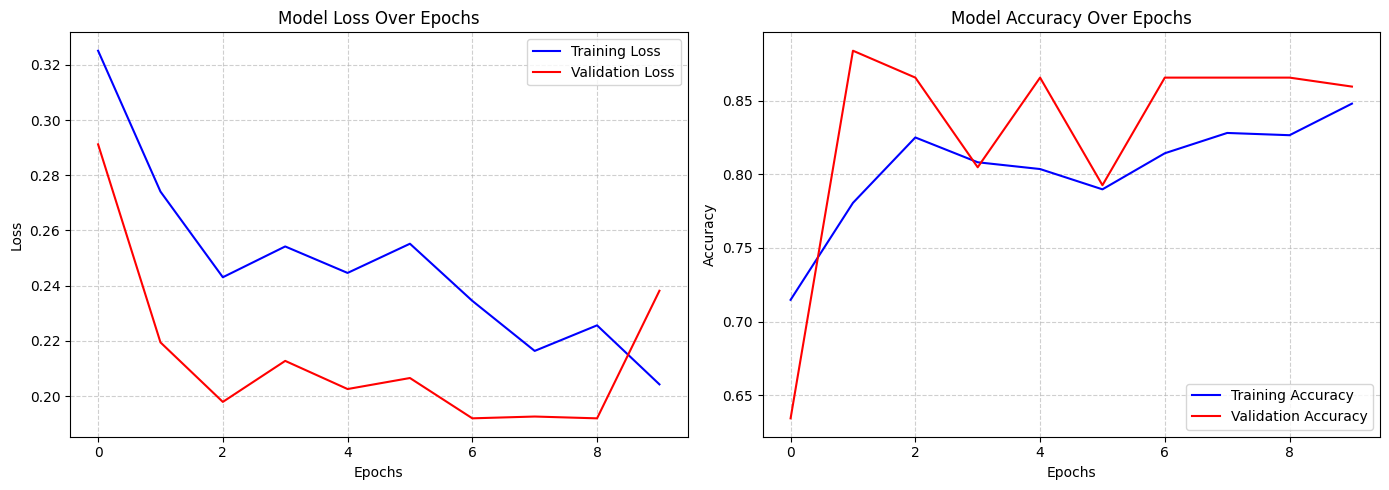


CLASSIFICATION REPORT
               precision    recall  f1-score   support

  Healthy (0)       0.76      0.78      0.77        50
Unhealthy (1)       0.90      0.89      0.90       114

     accuracy                           0.86       164
    macro avg       0.83      0.84      0.84       164
 weighted avg       0.86      0.86      0.86       164


CONFUSION MATRIX


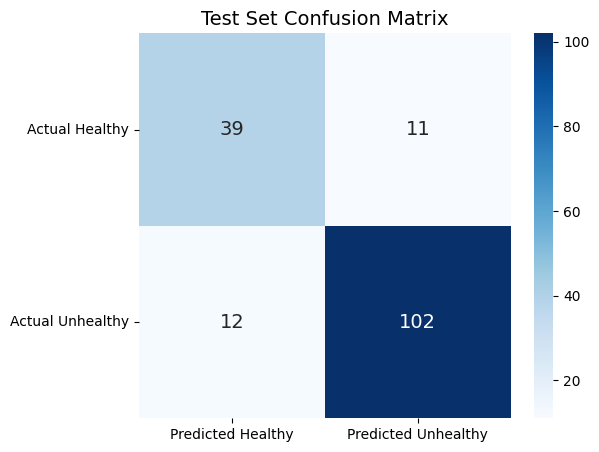

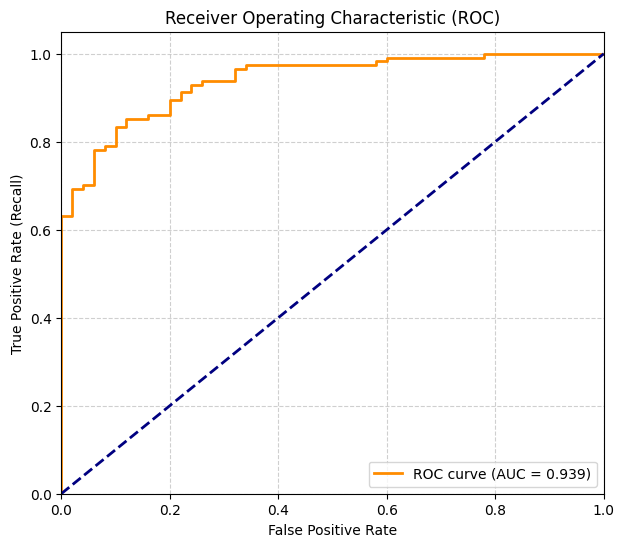

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ==========================================
# 1. PLOT TRAINING CURVES (Loss & Accuracy)
# ==========================================
# This uses the lists we populated during the training loop
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(train_losses, label='Training Loss', color='blue')
axes[0].plot(val_losses, label='Validation Loss', color='red')
axes[0].set_title('Model Loss Over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot Accuracy
axes[1].plot(train_accs, label='Training Accuracy', color='blue')
axes[1].plot(val_accs, label='Validation Accuracy', color='red')
axes[1].set_title('Model Accuracy Over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# ==========================================
# 2. RUN INFERENCE ON THE TEST SET
# ==========================================
model.eval()
all_predictions = []
all_true_labels = []
all_probabilities = []

with torch.no_grad():
    for images, features, labels in test_loader:
        images, features = images.to(device), features.to(device)
        
        # Get raw logits from the model
        outputs = model(images, features).squeeze()
        
        # Convert logits to probabilities (0.0 to 1.0) using Sigmoid
        probs = torch.sigmoid(outputs)
        
        # Round probabilities to strict 0 or 1
        preds = torch.round(probs)
        
        # Store results for sklearn metrics
        all_probabilities.extend(probs.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)


# ==========================================
# 3. CONFUSION MATRIX & CLASSIFICATION REPORT
# ==========================================
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
# Label 0 = Healthy, Label 1 = Unhealthy
print(classification_report(all_true_labels, all_predictions, 
                            target_names=['Healthy (0)', 'Unhealthy (1)']))

print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)

# Generate confusion matrix
cm = confusion_matrix(all_true_labels, all_predictions)

# Plot confusion matrix using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Healthy', 'Predicted Unhealthy'],
            yticklabels=['Actual Healthy', 'Actual Unhealthy'],
            annot_kws={"size": 14})
plt.title('Test Set Confusion Matrix', fontsize=14)
plt.yticks(rotation=0)
plt.show()


# ==========================================
# 4. ROC CURVE & AUC (Area Under Curve)
# ==========================================
# AUC is excellent for seeing how well the model separates the two classes
fpr, tpr, thresholds = roc_curve(all_true_labels, all_probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 50/50 Random Guess Line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [14]:
torch.save(model.state_dict(), 'stage1_healthy72_unhealthy96.pth')